# GBPUSD vs EURUSD — January 2025 mini-run

Minimal pipeline: load Jan 2025 ticks, refit cointegration + Markov regimes on a **3-day rolling window**, trade the **next day**, and **flatten at end-of-day** so each day is an independent experiment. No outer WFO — fixed trading-rule params.

In [1]:
!curl -sL https://raw.githubusercontent.com/egil10/stk-mat2011/main/code/scripts/colab.py -o /content/colab.py
import sys; sys.path.insert(0, '/content'); from colab import setup; setup('code/jan2025')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD:           /content/stk-mat2011/code/jan2025
engine.py:     True
Data symlink:  True -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed
Parquet count: 916
Path test:     True


In [2]:
%pip install --quiet arch optuna

import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd

from spread import SPREAD
from screener import SCREENER
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

In [3]:
# ---- Pair + data window ----
NAME_A, NAME_B = 'GBPUSD', 'EURUSD'
PAIR_NAME      = f'{NAME_A}_{NAME_B}'
MONTHS         = ['202501']
DATA_DIR       = '../data/processed'

# ---- Bar aggregation ----
# threshold=500 (vs 1000 in the big notebooks) gives ~2x more bars per day,
# which is what makes a 3-day training window viable for the HMM.
START_HOUR, END_HOUR = 0, 24
BAR_THRESHOLD        = 500

# ---- Engine (per-day rolling fit) ----
TRAIN_DAYS    = 3       # rolling training history
COINT_WINDOW  = 150     # rolling OLS window for beta/alpha
Z_WINDOW      = 50      # rolling z-score lookback
K_REGIMES     = 2       # quiet vs danger
WINSORIZE_STD = 4.0
SCALING       = 10000

# ---- Backtester trading-rule params (fixed; no WFO on a one-month slice) ----
Z_QUIET          = 1.3
Z_VOLATILE       = 2.5
EXIT_Z           = 0.0
DANGER_THRESHOLD = 0.30
FEE_BPS          = 0.5
SLIPPAGE_MODE    = 'half_spread'

# Treat each day as an independent trade: positions reset at EOD.
FLATTEN_EOD = True

In [4]:
def make_files(name_a, name_b, months):
    a, b = name_a.lower(), name_b.lower()
    return [
        [f'{DATA_DIR}/{a}_dukascopy_ask_{m}.parquet' for m in months],
        [f'{DATA_DIR}/{a}_dukascopy_bid_{m}.parquet' for m in months],
        [f'{DATA_DIR}/{b}_dukascopy_ask_{m}.parquet' for m in months],
        [f'{DATA_DIR}/{b}_dukascopy_bid_{m}.parquet' for m in months],
    ]

builder = SPREAD(
    agg_type='tick',
    threshold=BAR_THRESHOLD,
    active_hours=(START_HOUR, END_HOUR),
)
df = builder.build(make_files(NAME_A, NAME_B, MONTHS))

print(f'Bars  : {len(df):,}')
print(f'Range : {df.index.min()}  ->  {df.index.max()}')
print(f'Days  : {df.index.normalize().unique().shape[0]}')

built 5288 rows
Bars  : 5,288
Range : 2025-01-01 22:58:03.432000+00:00  ->  2025-01-31 21:59:56.085000+00:00
Days  : 23



=== COINTEGRATION SCREENER ===
Full: p=0.4351 | half-life=282.4 | β=0.9124

Rolling (1000-bar, step 100, n=43):
  p<0.05: 16.3% | p<0.10: 20.9%
  half-life: 23.0 (IQR 14–34)
  β: 1.0441 ±0.4030 [0.4155, 1.8607]


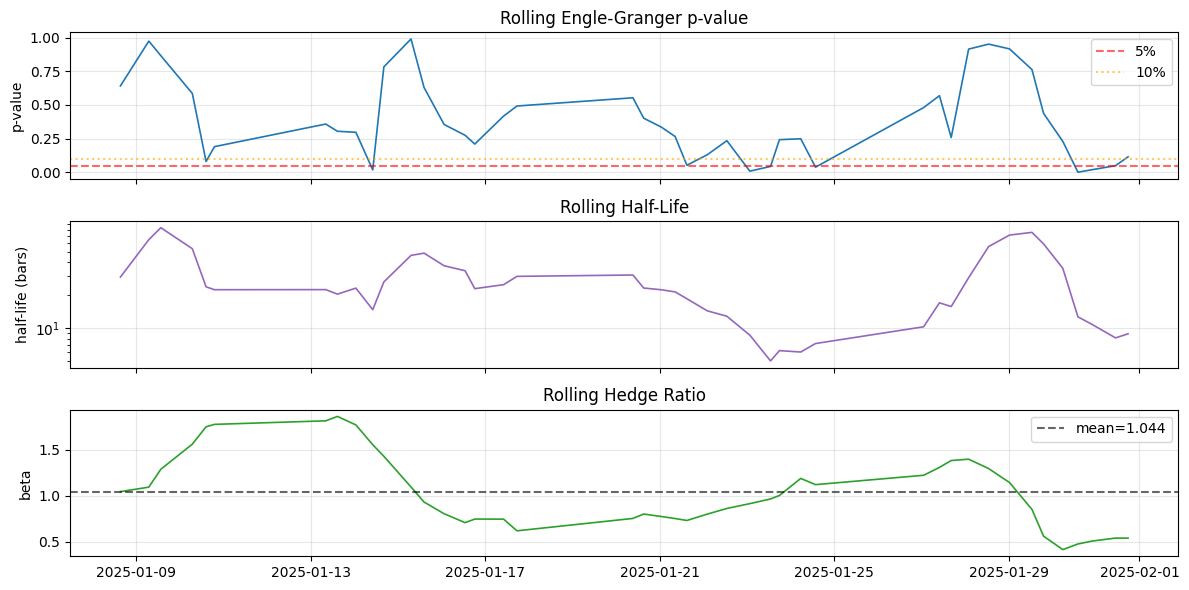

In [5]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report(rolling_window=1000, rolling_step=100)

In [6]:
live, df_params = ENGINE.walk_forward(
    df=df,
    train_days=TRAIN_DAYS,
    coint_window=COINT_WINDOW,
    z_window=Z_WINDOW,
    k_regimes=K_REGIMES,
    winsorize_std=WINSORIZE_STD,
    scaling=SCALING,
    print_freq=5,
)
print(f'\nOOS bars: {len(live):,}  |  Folds: {len(df_params)}')

Running Engine | train_days=3 | coint_window=150 | z_window=50 | k_regimes=2 | winsor=4.0σ | scale=x10000


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


[2025-01-08] Beta: 0.9225 | MR_rho: 0.2038 | DR_rho: 0.8305


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


[2025-01-15] Beta: 0.7297 | MR_rho: -0.1316 | DR_rho: 0.9494


...

[2025-01-22] Beta: 1.0816 | MR_rho: 0.8035 | DR_rho: 0.8627


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


[2025-01-29] Beta: 0.8344 | MR_rho: 0.9559 | DR_rho: 0.9960


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



OOS bars: 4,922  |  Folds: 20


In [7]:
bt = BACKTESTER(live)
results = bt.run(
    z_quiet=Z_QUIET,
    z_volatile=Z_VOLATILE,
    exit_z=EXIT_Z,
    danger_threshold=DANGER_THRESHOLD,
    fee_bps=FEE_BPS,
    slippage_mode=SLIPPAGE_MODE,
    flatten_eod=FLATTEN_EOD,
)
print(f'Backtest done. flatten_eod={FLATTEN_EOD}.')

Backtest done. flatten_eod=True.



                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | -70.90         | 1102.86        | 191.59         | 633.74         |
Annual Return (bps)            | -1035.78       | 16112.74       | 2799.19        | 9258.89        |
Best Month (bps)               | -70.90         | 1102.86        | 191.59         | 633.74         |
Worst Month (bps)              | -70.90         | 1102.86        | 191.59         | 633.74         |
Positive Months %              | 0.00%          | 100.00%        | 100.00%        | 100.00%        |

--- RISK ---
Annual Volatility (bps)        | 1190.78        | 942.41         | 379.66         | 806.12         |
Max Drawdown (bps)             | -280.42        | -75.52         | -62.54  

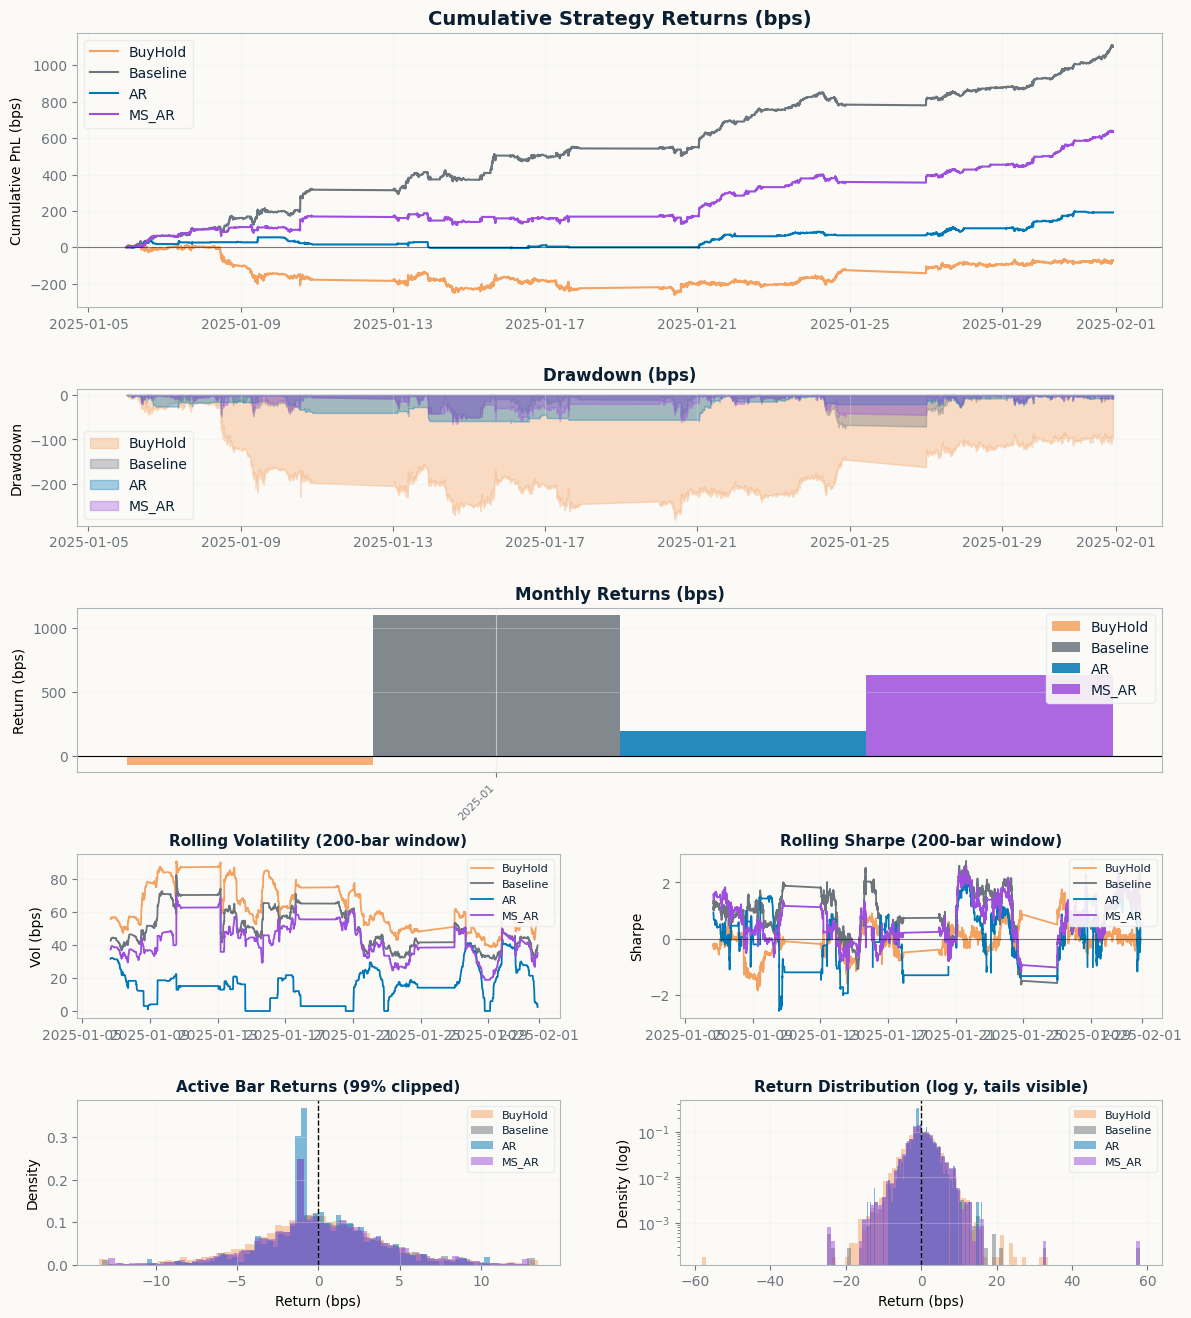

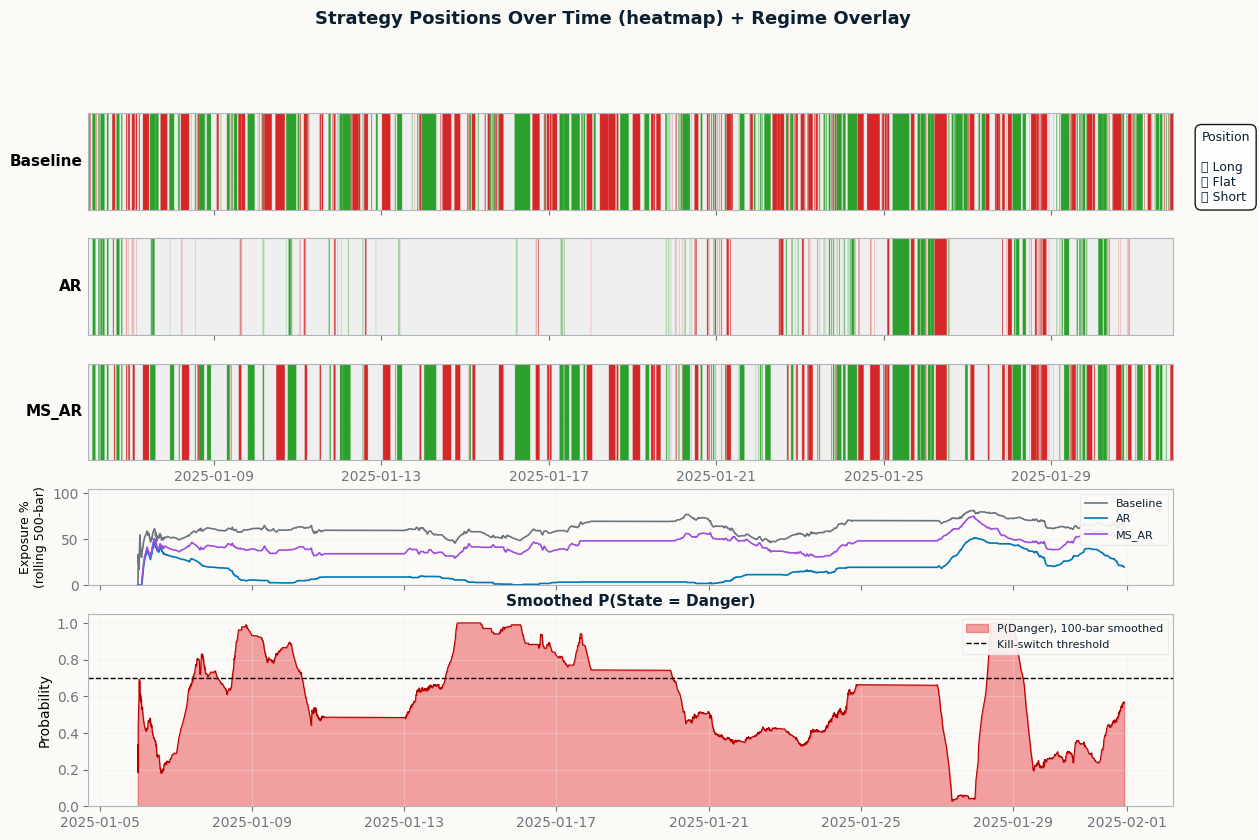

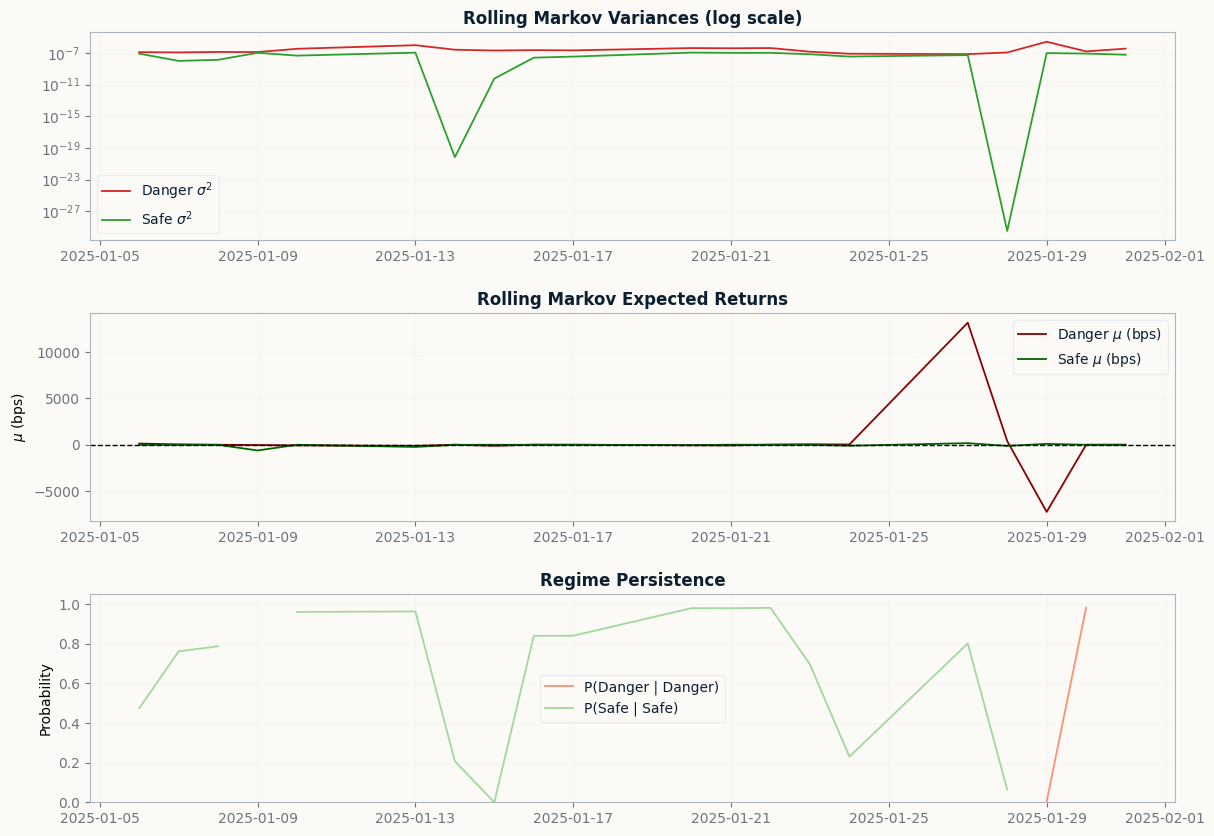

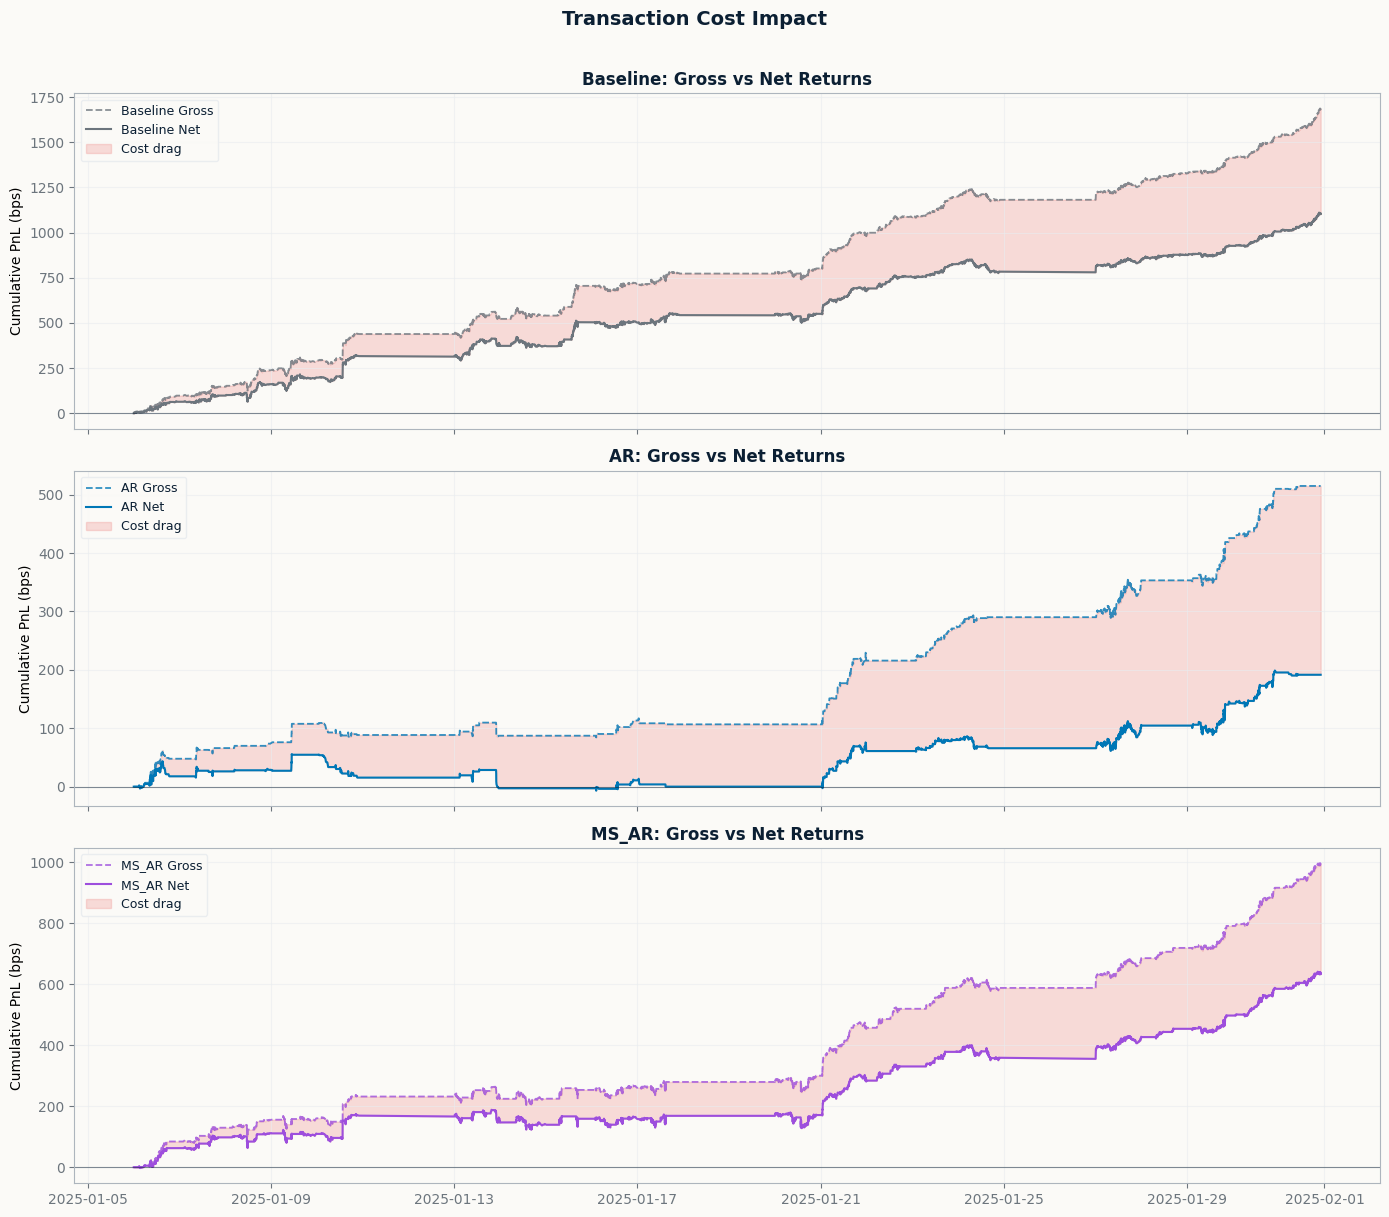

In [8]:
ts = TEARSHEET(results, df_params=df_params, pdf_prefix=f'{PAIR_NAME}_jan2025')
ts.generate_report()
ts.plot_performance()
ts.plot_positions_and_regimes()
ts.plot_markov_dynamics()
ts.plot_cost_impact()